In [1]:
!pip install mlflow dagshub -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 85.0 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 74.9 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 48.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

Initialized MLflow to track repo "ejoba22/IEEE-CIS-Fraud-Detection"

Repository ejoba22/IEEE-CIS-Fraud-Detection initialized!

2026/04/30 10:53:24 INFO mlflow.tracking.fluent: Experiment with name 'XGBoost_Training' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/9c7ba26706dc4d72b59e251123ee8592', creation_time=1777546404448, experiment_id='0', last_update_time=1777546404448, lifecycle_stage='active', name='XGBoost_Training', tags={}, trace_location=None, workspace='default'>

In [10]:
train_transaction = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv')
train_identity = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv')

train = train_transaction.merge(train_identity, on='TransactionID', how='left')

print("Train shape:", train.shape)
print("Columns:", train.columns.tolist())# 1. Basic Dataset Overview

Train shape: (590540, 434)
Test shape: (506691, 433)


# 1. Basic Dataset Overview

In [22]:
print("="*50)
print("DATASET OVERVIEW")
print("="*50)
print(f"Rows: {train.shape[0]:,}")
print(f"Columns: {train.shape[1]}")
print(f"\nData Types:")
print(train.dtypes.value_counts())
print(f"\nMemory Usage: {train.memory_usage().sum() / 1024**2:.2f} MB")

DATASET OVERVIEW
Rows: 590,540
Columns: 434

Data Types:
float64    399
object      31
int64        4
Name: count, dtype: int64

Memory Usage: 1955.37 MB


In [23]:
print("First 5 rows:")
train.head()

First 5 rows:


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [24]:
train.describe()

,TransactionID,isFraud,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,...,id_17,id_18,id_19,id_20,id_21,id_22,id_24,id_25,id_26,id_32
count,5.905400e+05,590540.000000,5.905400e+05,590540.000000,590540.000000,581607.000000,588975.000000,586281.000000,524834.000000,524834.000000,...,139369.000000,45113.000000,139318.000000,139261.000000,5159.000000,5169.000000,4747.000000,5132.000000,5163.000000,77586.000000
mean,3.282270e+06,0.034990,7.372311e+06,135.027176,9898.734658,362.555488,153.194925,199.278897,290.733794,86.800630,...,189.451377,14.237337,353.128174,403.882666,368.269820,16.002708,12.800927,329.608924,149.070308,26.508597
std,1.704744e+05,0.183755,4.617224e+06,239.162522,4901.170153,157.793246,11.336444,41.244453,101.741072,2.690623,...,30.375360,1.561302,141.095343,152.160327,198.847038,6.897665,2.372447,97.461089,32.101995,3.737502
min,2.987000e+06,0.000000,8.640000e+04,0.251000,1000.000000,100.000000,100.000000,100.000000,100.000000,10.000000,...,100.000000,10.000000,100.000000,100.000000,100.000000,10.000000,11.000000,100.000000,100.000000,0.000000
25%,3.134635e+06,0.000000,3.027058e+06,43.321000,6019.000000,214.000000,150.000000,166.000000,204.000000,87.000000,...,166.000000,13.000000,266.000000,256.000000,252.000000,14.000000,11.000000,321.000000,119.000000,24.000000
50%,3.282270e+06,0.000000,7.306528e+06,68.769000,9678.000000,361.000000,150.000000,226.000000,299.000000,87.000000,...,166.000000,15.000000,341.000000,472.000000,252.000000,14.000000,11.000000,321.000000,149.000000,24.000000
75%,3.429904e+06,0.000000,1.124662e+07,125.000000,14184.000000,512.000000,150.000000,226.000000,330.000000,87.000000,...,225.000000,15.000000,427.000000,533.000000,486.500000,14.000000,15.000000,371.000000,169.000000,32.000000
max,3.577539e+06,1.000000,1.581113e+07,31937.391000,18396.000000,600.000000,231.000000,237.000000,540.000000,102.000000,...,229.000000,29.000000,671.000000,661.000000,854.000000,44.000000,26.000000,548.000000,216.000000,32.000000


# 2. Target Variable Analysis

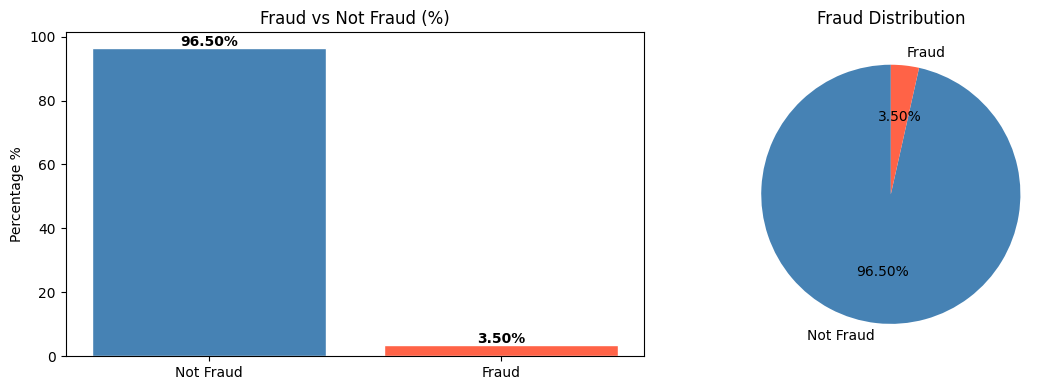

Total transactions: 590,540
Fraud cases: 20,663 (3.50%)
Not Fraud cases: 569,877 (96.50%)


In [27]:
# ── Fraud ratio ────────────────────────────────────
fraud_ratio = train['isFraud'].value_counts(normalize=True) * 100
fraud_count = train['isFraud'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar plot
axes[0].bar(['Not Fraud', 'Fraud'], fraud_ratio.values, 
            color=['steelblue', 'tomato'], edgecolor='white')
axes[0].set_title('Fraud vs Not Fraud (%)')
axes[0].set_ylabel('Percentage %')
for i, v in enumerate(fraud_ratio.values):
    axes[0].text(i, v + 0.5, f'{v:.2f}%', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(fraud_count.values, labels=['Not Fraud', 'Fraud'],
            colors=['steelblue', 'tomato'], autopct='%1.2f%%',
            startangle=90)
axes[1].set_title('Fraud Distribution')

plt.tight_layout()
plt.show()

print(f"Total transactions: {len(train):,}")
print(f"Fraud cases: {fraud_count[1]:,} ({fraud_ratio[1]:.2f}%)")
print(f"Not Fraud cases: {fraud_count[0]:,} ({fraud_ratio[0]:.2f}%)")

# 3. Transaction Amount Analysis

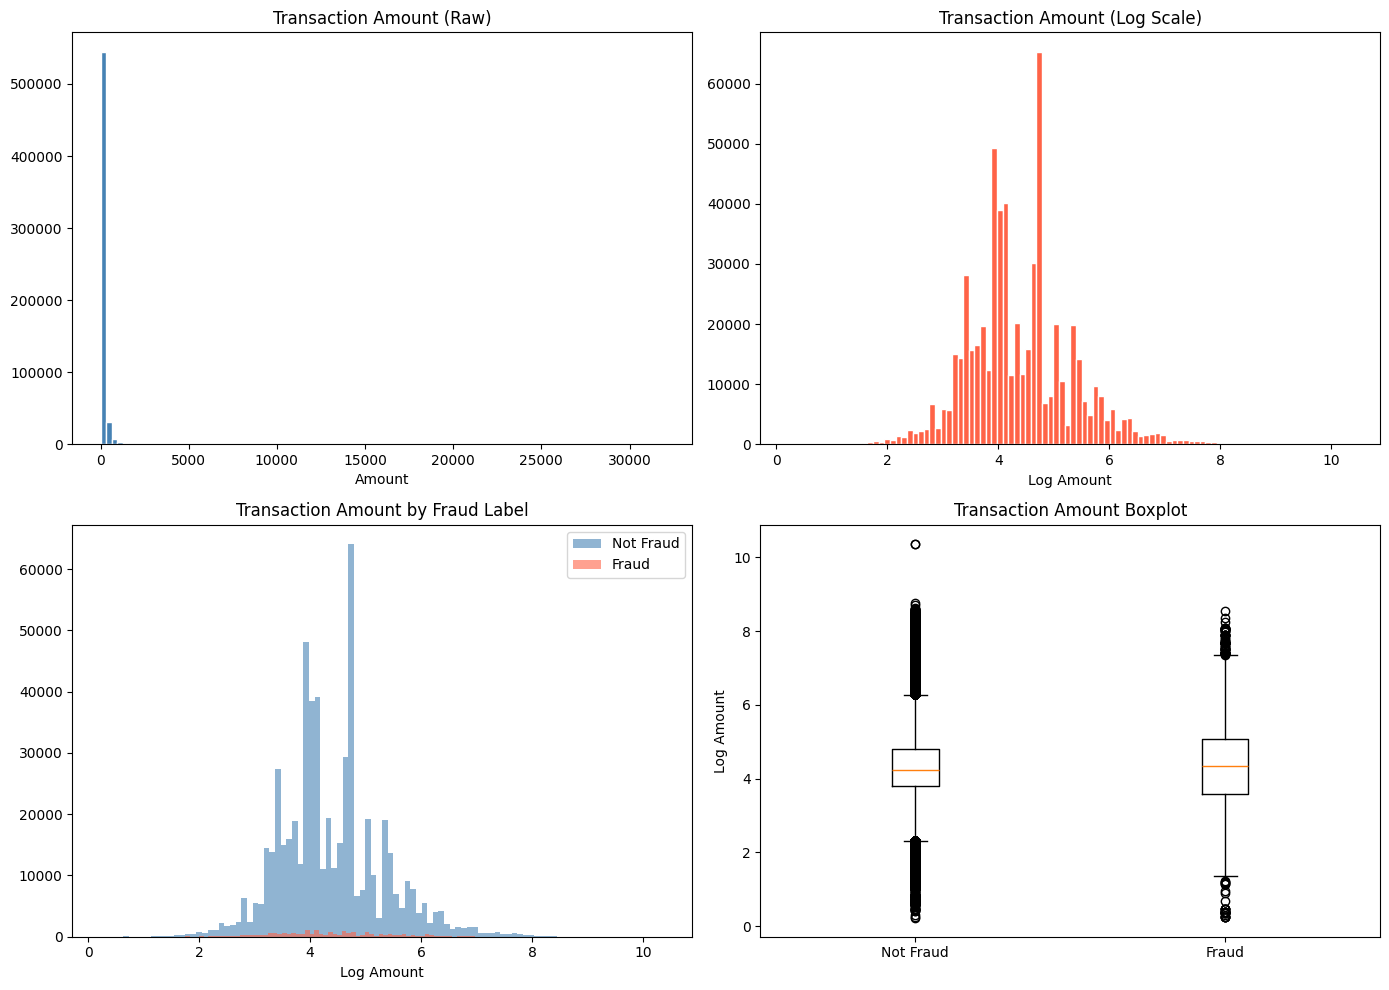

Mean transaction amount: $135.03
Median transaction amount: $68.77
Max transaction amount: $31937.39

Fraud mean amount: $149.24
Not Fraud mean amount: $134.51


In [29]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Raw distribution
axes[0,0].hist(train['TransactionAmt'], bins=100, color='steelblue', edgecolor='white')
axes[0,0].set_title('Transaction Amount (Raw)')
axes[0,0].set_xlabel('Amount')

# Log distribution
axes[0,1].hist(np.log1p(train['TransactionAmt']), bins=100, color='tomato', edgecolor='white')
axes[0,1].set_title('Transaction Amount (Log Scale)')
axes[0,1].set_xlabel('Log Amount')

# By fraud label
axes[1,0].hist(np.log1p(train[train['isFraud']==0]['TransactionAmt']), 
               bins=100, alpha=0.6, color='steelblue', label='Not Fraud')
axes[1,0].hist(np.log1p(train[train['isFraud']==1]['TransactionAmt']), 
               bins=100, alpha=0.6, color='tomato', label='Fraud')
axes[1,0].set_title('Transaction Amount by Fraud Label')
axes[1,0].set_xlabel('Log Amount')
axes[1,0].legend()

# Boxplot
axes[1,1].boxplot([
    np.log1p(train[train['isFraud']==0]['TransactionAmt']),
    np.log1p(train[train['isFraud']==1]['TransactionAmt'])
], labels=['Not Fraud', 'Fraud'])
axes[1,1].set_title('Transaction Amount Boxplot')
axes[1,1].set_ylabel('Log Amount')

plt.tight_layout()
plt.show()

print(f"Mean transaction amount: ${train['TransactionAmt'].mean():.2f}")
print(f"Median transaction amount: ${train['TransactionAmt'].median():.2f}")
print(f"Max transaction amount: ${train['TransactionAmt'].max():.2f}")
print(f"\nFraud mean amount: ${train[train['isFraud']==1]['TransactionAmt'].mean():.2f}")
print(f"Not Fraud mean amount: ${train[train['isFraud']==0]['TransactionAmt'].mean():.2f}")

# 4. Missing Values Analysis

Total columns: 434
Columns with missing values: 414
Columns with >90% missing: 12
Columns with >50% missing: 214
Columns with no missing: 20


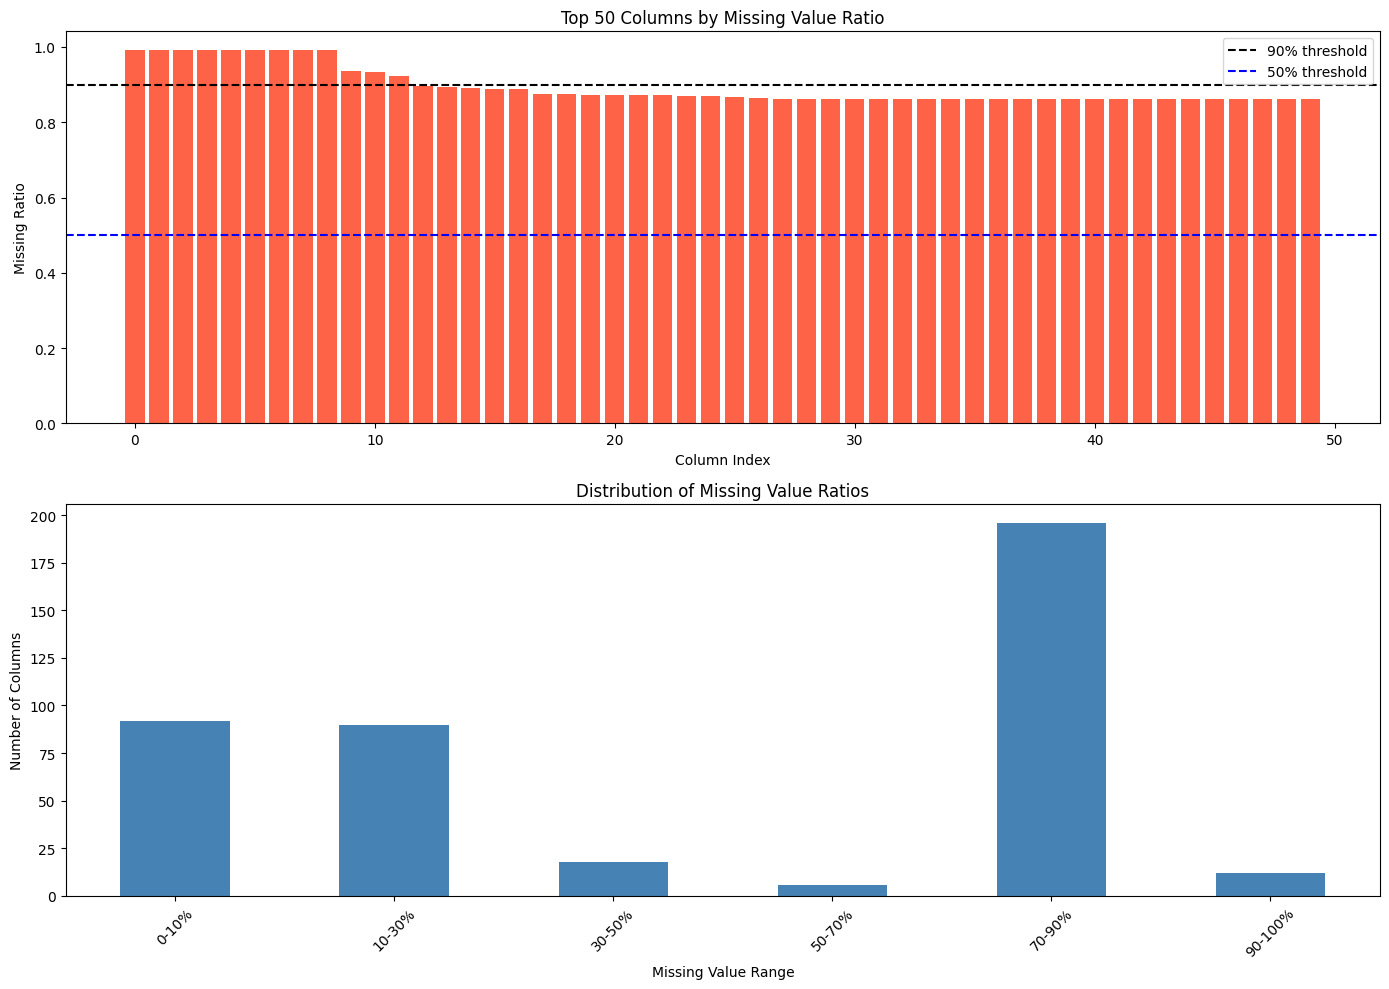

In [31]:
# missing val analysis
missing = train.isnull().mean().sort_values(ascending=False)
missing_count = train.isnull().sum().sort_values(ascending=False)

print(f"Total columns: {len(train.columns)}")
print(f"Columns with missing values: {(missing > 0).sum()}")
print(f"Columns with >90% missing: {(missing > 0.9).sum()}")
print(f"Columns with >50% missing: {(missing > 0.5).sum()}")
print(f"Columns with no missing: {(missing == 0).sum()}")

# top 50 missing columns
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

missing_top50 = missing[missing > 0].head(50)
axes[0].bar(range(len(missing_top50)), missing_top50.values, color='tomato')
axes[0].set_title('Top 50 Columns by Missing Value Ratio')
axes[0].set_ylabel('Missing Ratio')
axes[0].set_xlabel('Column Index')
axes[0].axhline(0.9, color='black', linestyle='--', label='90% threshold')
axes[0].axhline(0.5, color='blue', linestyle='--', label='50% threshold')
axes[0].legend()

# missing val distributions
missing_bins = [0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
missing_labels = ['0-10%', '10-30%', '30-50%', '50-70%', '70-90%', '90-100%']
missing_groups = pd.cut(missing[missing > 0], bins=missing_bins, labels=missing_labels)
missing_groups.value_counts().sort_index().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Distribution of Missing Value Ratios')
axes[1].set_ylabel('Number of Columns')
axes[1].set_xlabel('Missing Value Range')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 5. Time Analysis

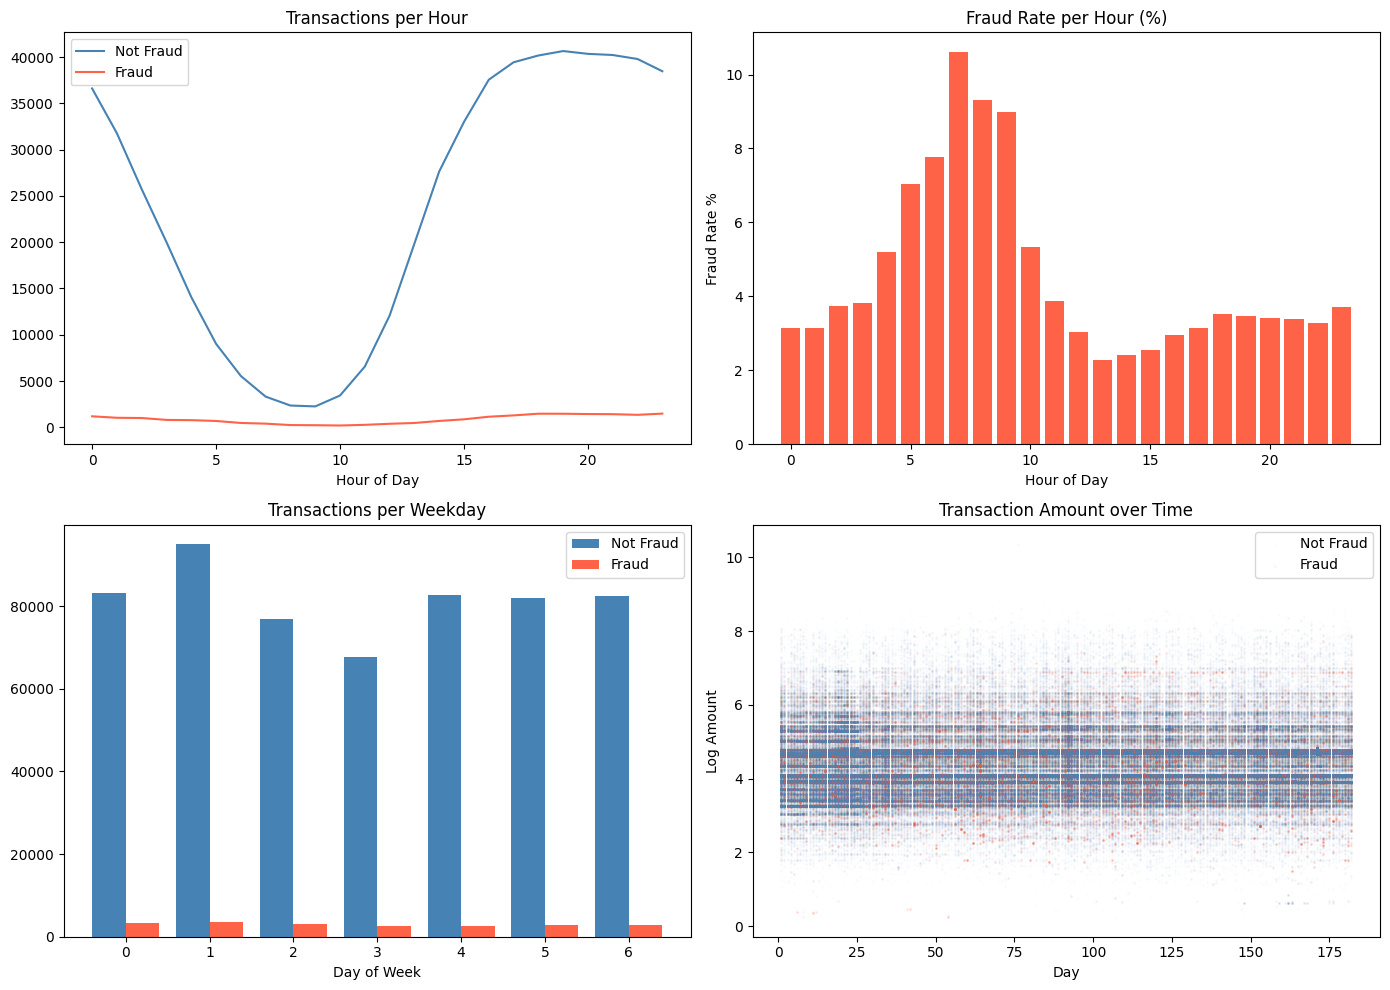

In [32]:
train['Transaction_hour'] = (train['TransactionDT'] // 3600) % 24
train['Transaction_day'] = train['TransactionDT'] // (3600 * 24)
train['Transaction_weekday'] = train['Transaction_day'] % 7

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

#per hour
hour_fraud = train[train['isFraud']==1].groupby('Transaction_hour').size()
hour_notfraud = train[train['isFraud']==0].groupby('Transaction_hour').size()
hour_fraud_rate = train.groupby('Transaction_hour')['isFraud'].mean() * 100

axes[0,0].plot(hour_notfraud.index, hour_notfraud.values, color='steelblue', label='Not Fraud')
axes[0,0].plot(hour_fraud.index, hour_fraud.values, color='tomato', label='Fraud')
axes[0,0].set_title('Transactions per Hour')
axes[0,0].set_xlabel('Hour of Day')
axes[0,0].legend()

# fraud rate per hour
axes[0,1].bar(hour_fraud_rate.index, hour_fraud_rate.values, color='tomato')
axes[0,1].set_title('Fraud Rate per Hour (%)')
axes[0,1].set_xlabel('Hour of Day')
axes[0,1].set_ylabel('Fraud Rate %')

# per weekday
day_fraud = train[train['isFraud']==1].groupby('Transaction_weekday').size()
day_notfraud = train[train['isFraud']==0].groupby('Transaction_weekday').size()

axes[1,0].bar(day_notfraud.index - 0.2, day_notfraud.values, 
              width=0.4, color='steelblue', label='Not Fraud')
axes[1,0].bar(day_fraud.index + 0.2, day_fraud.values, 
              width=0.4, color='tomato', label='Fraud')
axes[1,0].set_title('Transactions per Weekday')
axes[1,0].set_xlabel('Day of Week')
axes[1,0].legend()

# over time
axes[1,1].scatter(train[train['isFraud']==0]['Transaction_day'],
                  np.log1p(train[train['isFraud']==0]['TransactionAmt']),
                  alpha=0.01, s=1, color='steelblue', label='Not Fraud')
axes[1,1].scatter(train[train['isFraud']==1]['Transaction_day'],
                  np.log1p(train[train['isFraud']==1]['TransactionAmt']),
                  alpha=0.05, s=1, color='tomato', label='Fraud')
axes[1,1].set_title('Transaction Amount over Time')
axes[1,1].set_xlabel('Day')
axes[1,1].set_ylabel('Log Amount')
axes[1,1].legend()

plt.tight_layout()
plt.show()

# 6. Categorical Features Analysis

Total categorical columns: 31
Columns: ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']


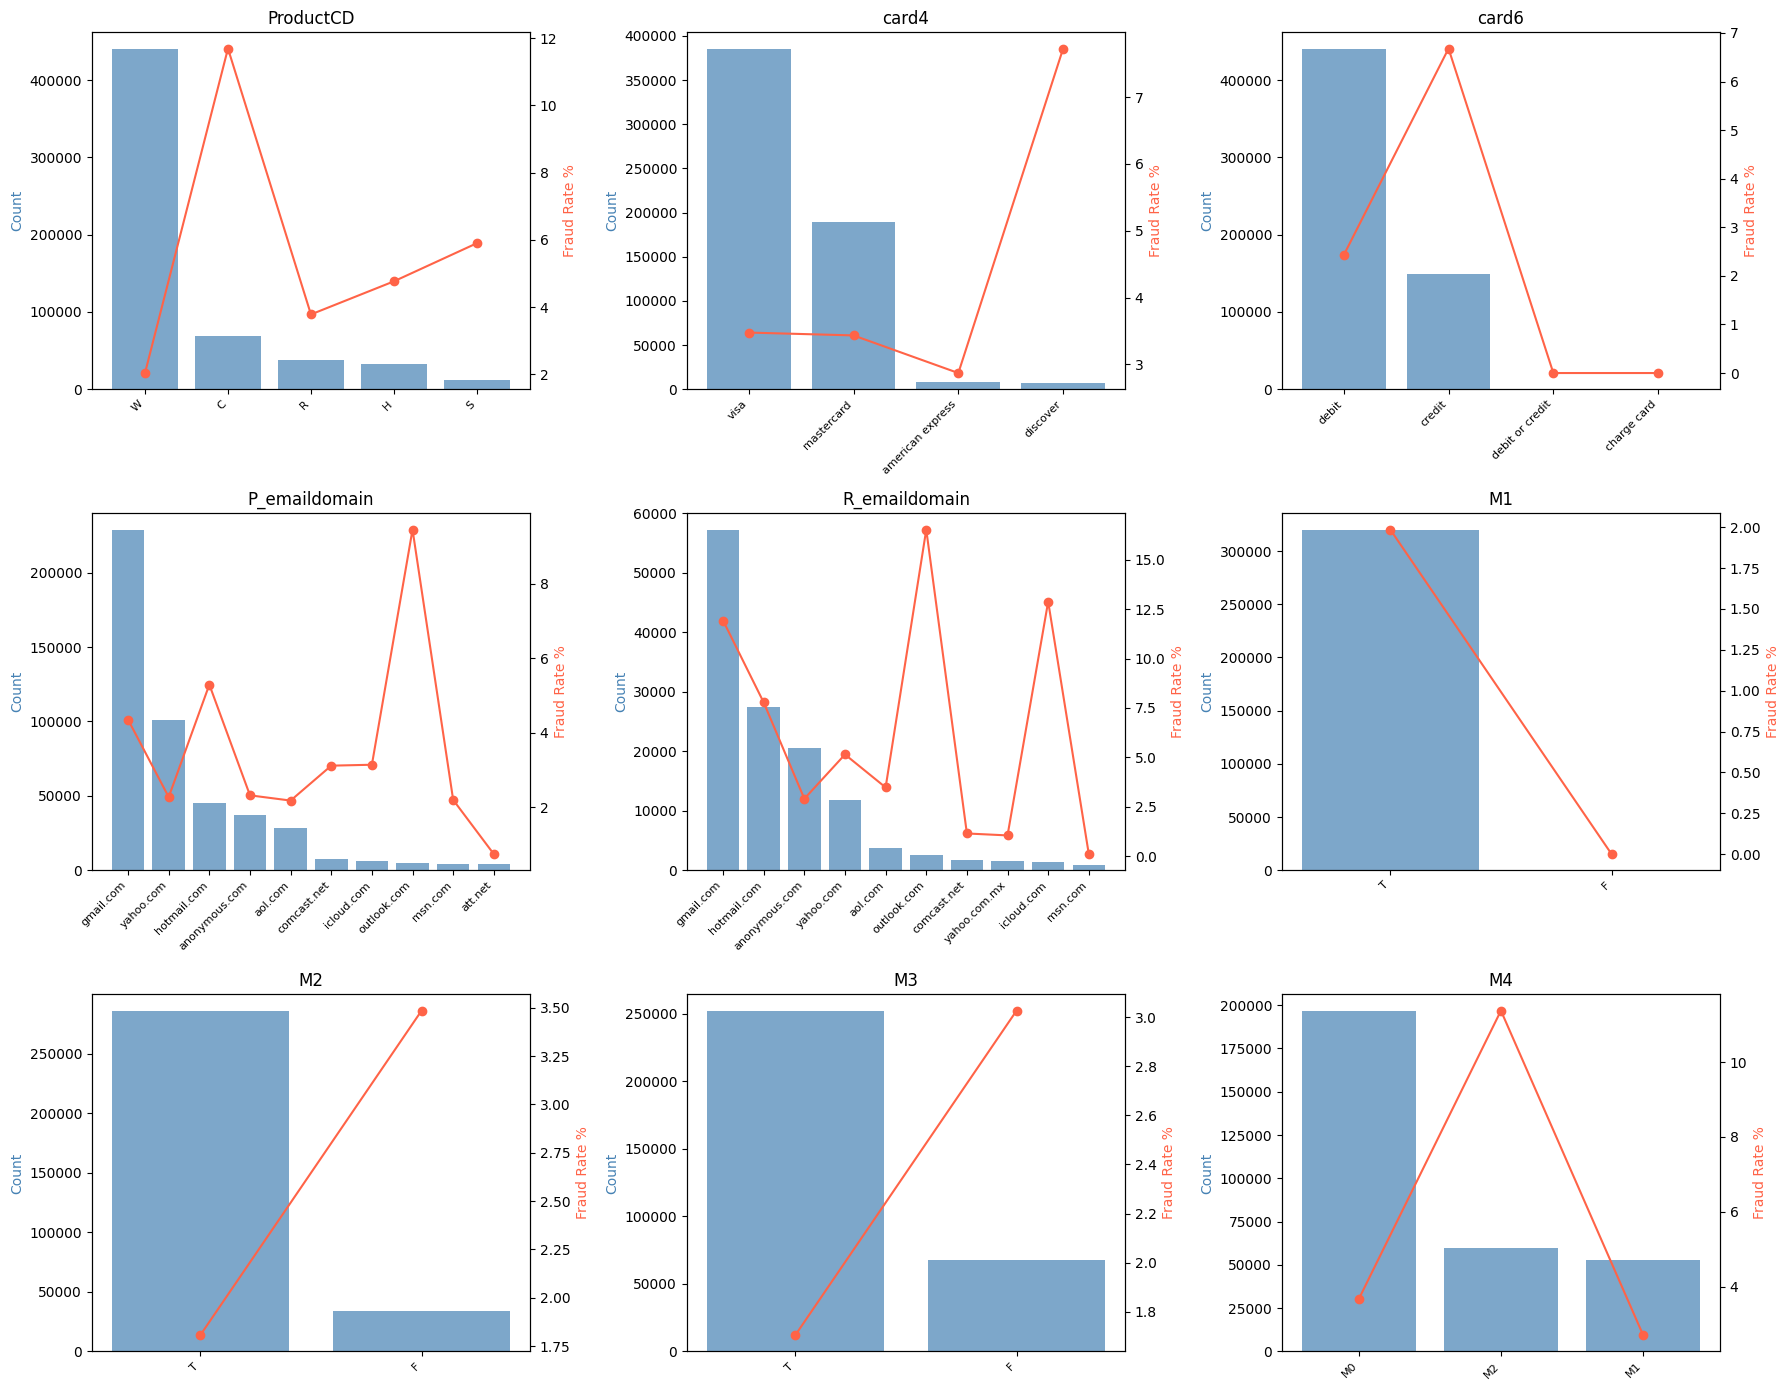

In [33]:
cat_cols = train.select_dtypes(include='object').columns.tolist()
print(f"Total categorical columns: {len(cat_cols)}")
print(f"Columns: {cat_cols}")

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(cat_cols[:9]):
    top_vals = train[col].value_counts().head(10)
    
    fraud_rate = train.groupby(col)['isFraud'].mean() * 100
    fraud_rate_top = fraud_rate[top_vals.index]
    
    ax1 = axes[i]
    ax2 = ax1.twinx()
    
    ax1.bar(range(len(top_vals)), top_vals.values, color='steelblue', alpha=0.7, label='Count')
    ax2.plot(range(len(fraud_rate_top)), fraud_rate_top.values, 
             color='tomato', marker='o', label='Fraud Rate %')
    
    ax1.set_title(f'{col}')
    ax1.set_xticks(range(len(top_vals)))
    ax1.set_xticklabels(top_vals.index.astype(str), rotation=45, ha='right', fontsize=8)
    ax1.set_ylabel('Count', color='steelblue')
    ax2.set_ylabel('Fraud Rate %', color='tomato')

plt.tight_layout()
plt.show()

# 7. Numerical Features Analysis

Top 15 features correlated with isFraud:
V257    0.383060
V246    0.366878
V244    0.364129
V242    0.360590
V201    0.328005
V200    0.318783
V189    0.308219
V188    0.303582
V258    0.297151
V45     0.281832
V158    0.278066
V156    0.275952
V149    0.273282
V228    0.268861
V44     0.260376
dtype: float64


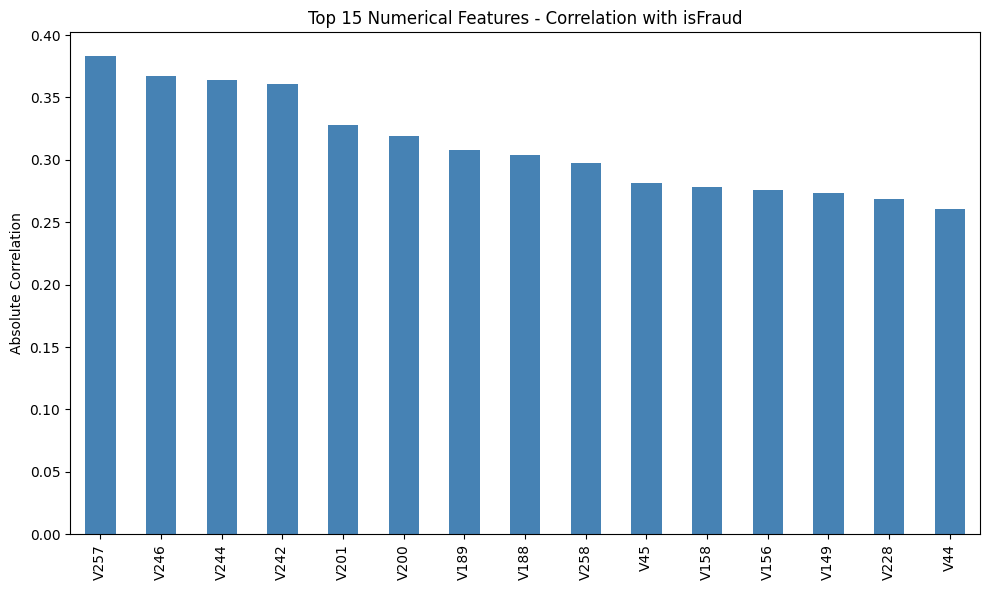

In [34]:
num_cols = train.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c not in ['isFraud', 'TransactionID', 'TransactionDT']]

top_corr = train[num_cols].corrwith(train['isFraud']).abs().sort_values(ascending=False).head(15)

print("Top 15 features correlated with isFraud:")
print(top_corr)

plt.figure(figsize=(10, 6))
top_corr.plot(kind='bar', color='steelblue')
plt.title('Top 15 Numerical Features - Correlation with isFraud')
plt.ylabel('Absolute Correlation')
plt.tight_layout()
plt.show()

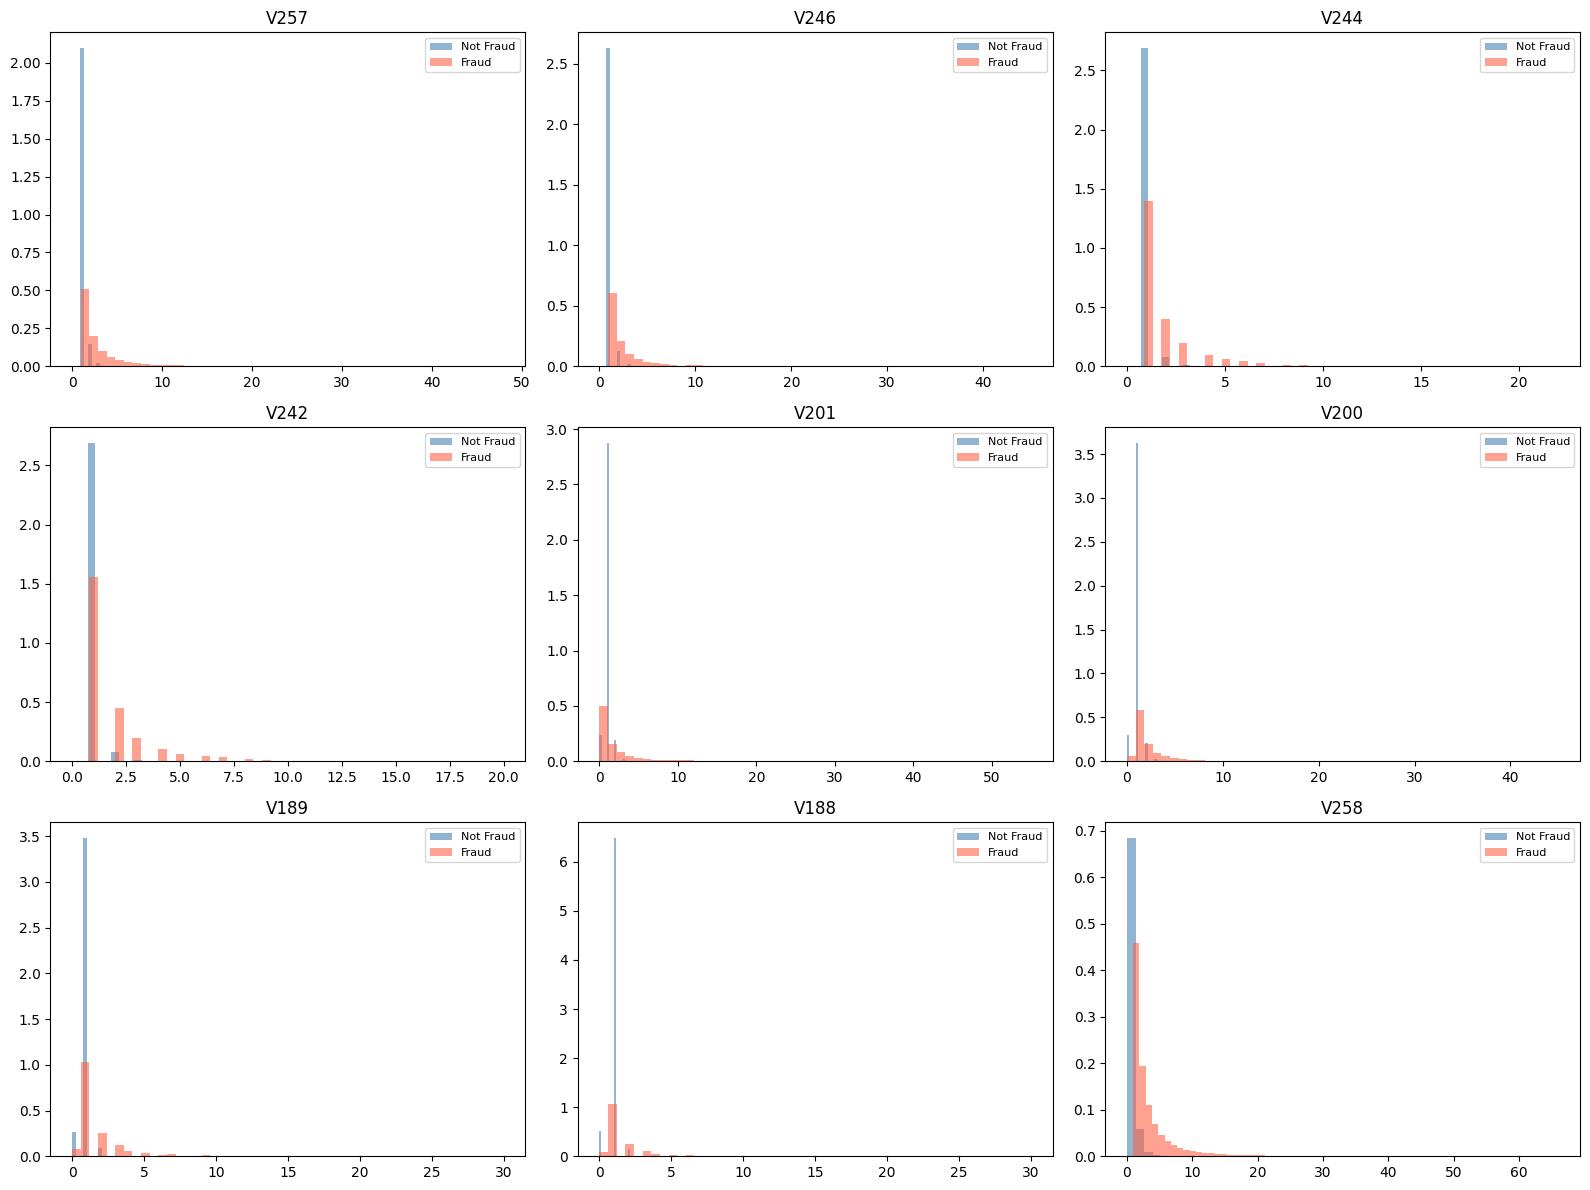

In [35]:
top_features = top_corr.head(9).index.tolist()

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(top_features):
    axes[i].hist(train[train['isFraud']==0][col].dropna(), 
                 bins=50, alpha=0.6, color='steelblue', label='Not Fraud', density=True)
    axes[i].hist(train[train['isFraud']==1][col].dropna(), 
                 bins=50, alpha=0.6, color='tomato', label='Fraud', density=True)
    axes[i].set_title(f'{col}')
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

# 8. Correlation Heatmap

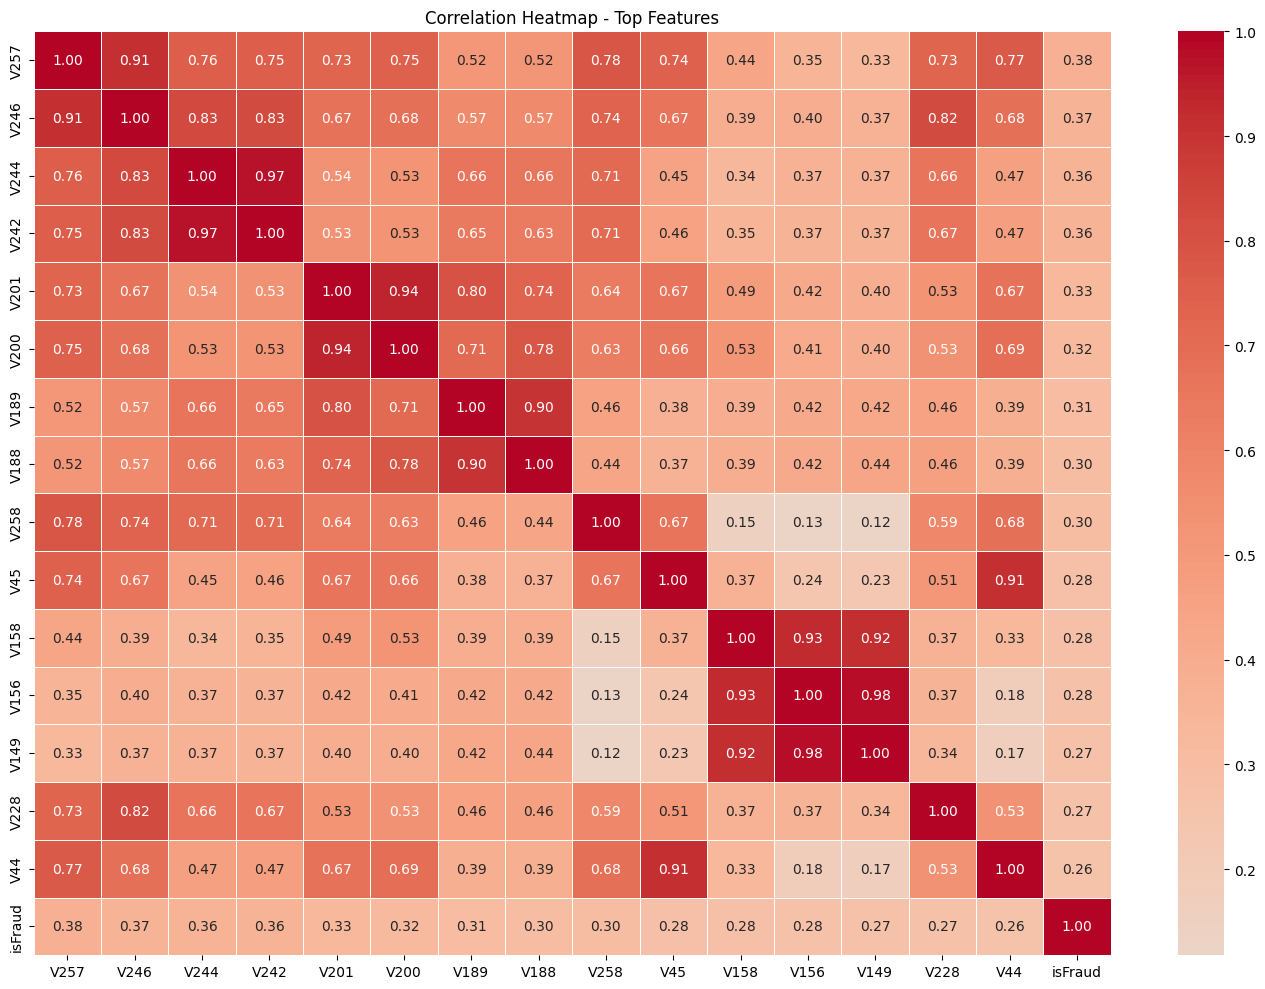

In [36]:
top_corr_cols = train[num_cols].corrwith(train['isFraud']).abs().sort_values(ascending=False).head(15).index.tolist()
top_corr_cols.append('isFraud')

plt.figure(figsize=(14, 10))
sns.heatmap(train[top_corr_cols].corr(), 
            annot=True, fmt='.2f',
            cmap='coolwarm', 
            linewidths=0.5,
            center=0)
plt.title('Correlation Heatmap - Top Features')
plt.tight_layout()
plt.show()

# 9. Outlier Analysis

Outlier Analysis using IQR method:
V257: 14,595 outliers (2.47%)
V246: 11,056 outliers (1.87%)
V244: 7,847 outliers (1.33%)
V242: 7,790 outliers (1.32%)
V201: 23,407 outliers (3.96%)
V200: 22,069 outliers (3.74%)
V189: 16,656 outliers (2.82%)
V188: 15,879 outliers (2.69%)
V258: 17,477 outliers (2.96%)
V45: 34,544 outliers (5.85%)


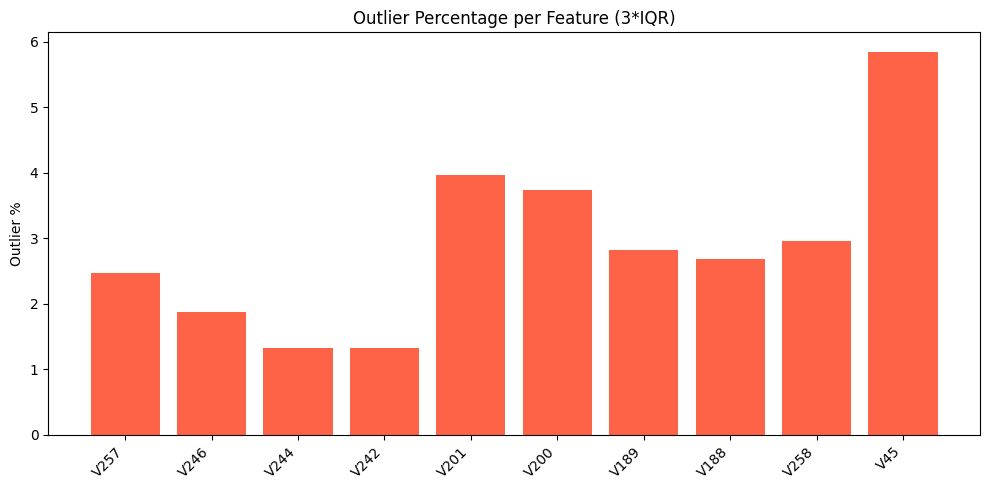

In [37]:
print("Outlier Analysis using IQR method:")
print("="*50)

outlier_summary = []

for col in top_corr.head(10).index:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((train[col] < Q1 - 3*IQR) | (train[col] > Q3 + 3*IQR)).sum()
    outlier_pct = outliers / len(train) * 100
    outlier_summary.append({'Feature': col, 'Outliers': outliers, 'Percentage': outlier_pct})
    print(f"{col}: {outliers:,} outliers ({outlier_pct:.2f}%)")

outlier_df = pd.DataFrame(outlier_summary)
plt.figure(figsize=(10, 5))
plt.bar(outlier_df['Feature'], outlier_df['Percentage'], color='tomato')
plt.title('Outlier Percentage per Feature (3*IQR)')
plt.ylabel('Outlier %')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()